In [ ]:
# Import essential libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Define class names for visualization
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Note: CIFAR-10 loaded shape is already (num_samples, 32, 32, 3)

# 2. Normalize pixel values to the range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 3. One-hot encode the labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# 4. Build the CNN Model (Adjusted input_shape for 3 channels)
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# 5. Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 6. Train the model
# (Note: CIFAR-10 features are more complex, so you might want to increase epochs to 10 or 15 later)
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)

# 7. Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
352/352 - 58s - 164ms/step - accuracy: 0.3630 - loss: 1.7414 - val_accuracy: 0.4898 - val_loss: 1.4224
Epoch 2/5
352/352 - 54s - 153ms/step - accuracy: 0.4887 - loss: 1.4332 - val_accuracy: 0.5738 - val_loss: 1.2395
Epoch 3/5
352/352 - 81s - 231ms/step - accuracy: 0.5382 - loss: 1.3008 - val_accuracy: 0.6050 - val_loss: 1.1358
Epoch 4/5
352/352 - 55s - 156ms/step - accuracy: 0.5722 - loss: 1.2129 - val_accuracy: 0.6058 - val_loss: 1.1338
Epoch 5/5
352/352 - 54s - 153ms/step - accuracy: 0.5952 - loss: 1.1415 - val_accuracy: 0.6498 - val_loss: 1.0109
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6368 - loss: 1.0250

Test Accuracy: 0.6368
Test Loss: 1.0250


In [ ]:
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

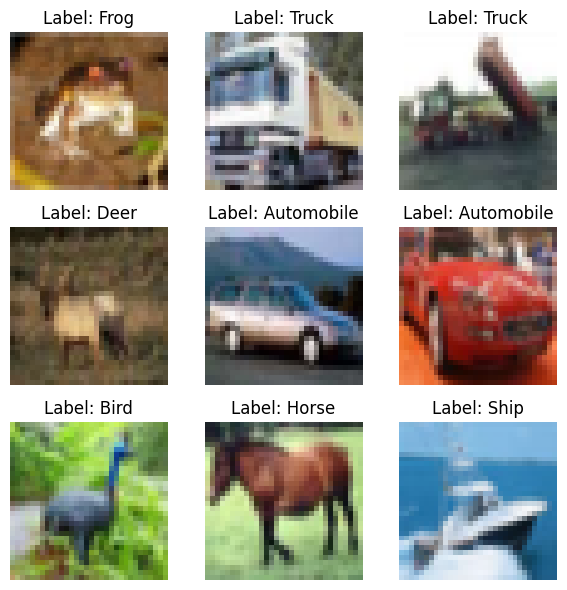

In [ ]:
# Visualize the first 9 color images
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i])  # No reshape needed for color images
    plt.title(f"Label: {class_names[np.argmax(y_train[i])]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step


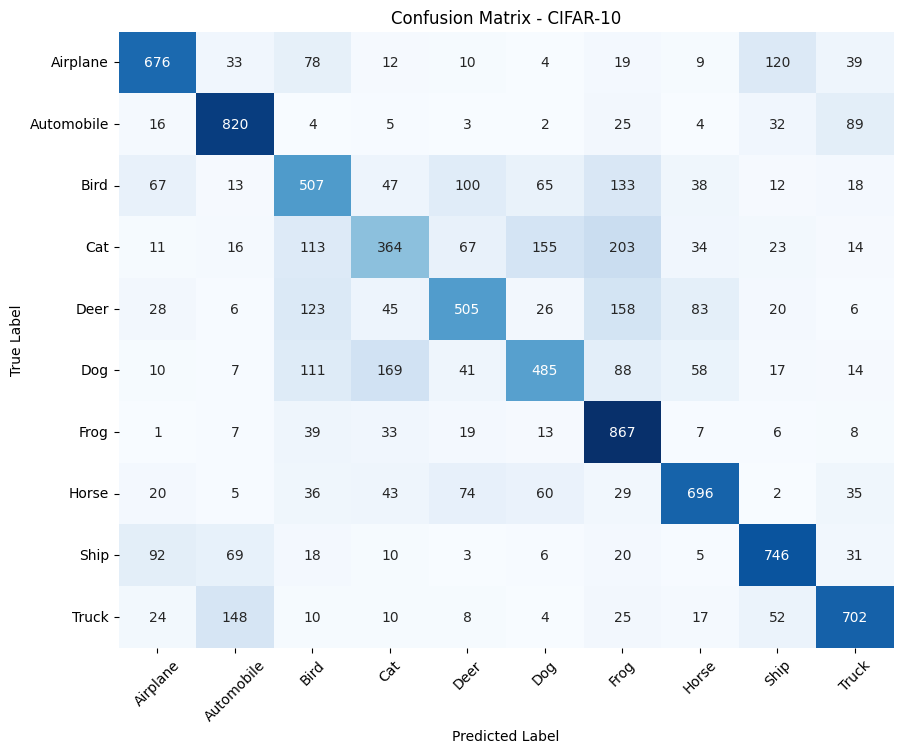

In [ ]:
# Predict the classes
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.squeeze(np.argmax(y_test, axis=1)) # Squeeze helps fix potential shape mismatches

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix with class names
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - CIFAR-10")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

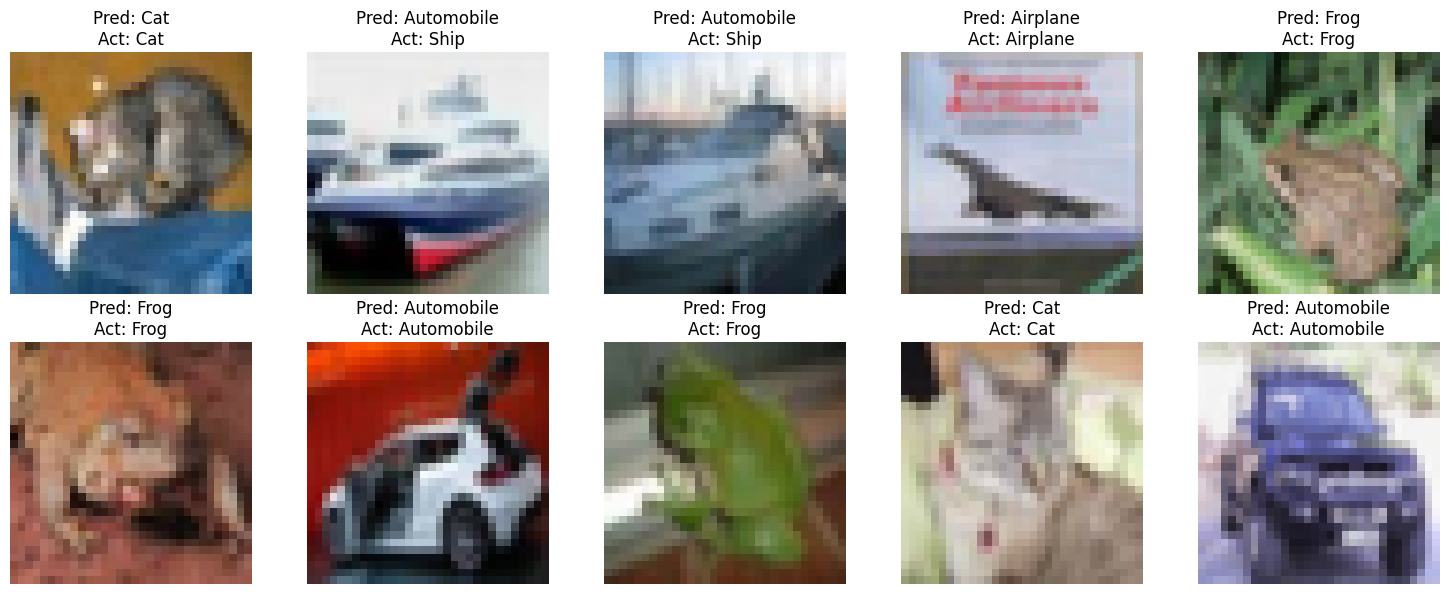

In [ ]:
# Plot 10 test images with predictions
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i])  # Displays original RGB color image
    plt.title(f"Pred: {class_names[y_pred_classes[i]]}\nAct: {class_names[y_true[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


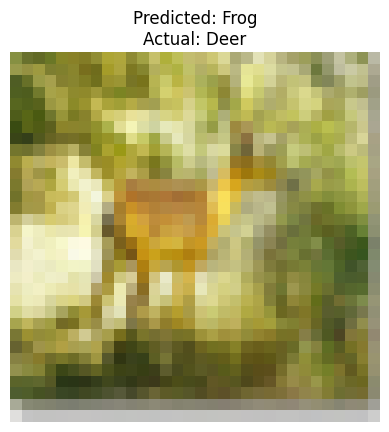

In [ ]:
# Predict a single image (e.g., index 500)
index = 500
single_image = x_test[index].reshape(1, 32, 32, 3) # Adjusted dimensions for 3 color channels

# Predict and show result
predicted_label = np.argmax(model.predict(single_image))
actual_label = np.squeeze(np.argmax(y_test[index]))

plt.imshow(x_test[index])
plt.title(f"Predicted: {class_names[predicted_label]}\nActual: {class_names[actual_label]}")
plt.axis('off')
plt.show()